# First look at a CNN

### Dataset: CIFAR-10
From https://www.cs.toronto.edu/~kriz/cifar.html:
"The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

In [18]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential


#### Getting and visualizing the data

In [19]:
# Loading the CIFAR-10 dataset
cifar10 = datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [20]:
# Convert pixel intensities to double values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


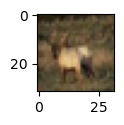

In [21]:
plt.figure(figsize=(1, 1))
plt.imshow(x_train[3])
plt.show()

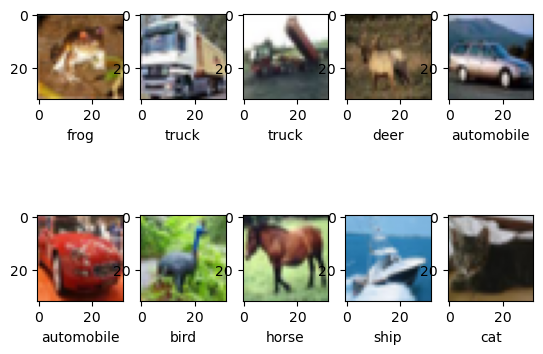

In [22]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

for i in range(10): # first 10 images from the training set
    plt.subplot(2,5,i+1)
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

## Create a Dense Neuron Network Model

#### Create a Dense Neural Network Model:

Start by building a sequential model, which allows you to stack layers in order.
Add a Flatten Layer:

The first layer should be a Flatten layer. This layer will take a 2D input (image) and reshape it into a 1D vector. This is necessary to prepare the data for the fully connected dense layers.
Add Two Dense Layers:

The first dense layer has 128 neurons with the ReLU activation function. This layer learns patterns in the data by applying weights and biases to each neuron.
The second dense layer has 512 neurons, also using the ReLU activation function. This layer adds more learning capacity to the model, helping it capture more complex patterns.
Add an Output Layer:

The final layer has 10 neurons with the softmax activation function. Each neuron in this layer represents a class (0–9) and outputs a probability score. The class with the highest probability will be the model's prediction.
This model structure is suitable for a classification task with 10 output classes, such as recognizing handwritten digits (0-9).

In [23]:
# Build the NN model
model = Sequential([
    Flatten(),
    Dense(128, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax') 
])

#### Compiling the model

Instructions for Compiling the Model:

Set the Optimizer:

Use the Adam optimizer by setting optimizer="adam". This is an adaptive optimization algorithm that adjusts the learning rate dynamically, helping the model converge more efficiently during training.
Define the Loss Function:

Set loss='sparse_categorical_crossentropy' as the loss function. This loss is suitable for multi-class classification tasks where the labels are provided as integer values (e.g., classes 0–9). It calculates how well the model’s predictions match the true labels, helping it to improve.
Set the Evaluation Metric:

Add metrics=['accuracy'] to monitor the model’s accuracy during training. Accuracy represents the percentage of correct predictions and gives a clear measure of the model’s performance on both training and validation data.
By compiling the model with these settings, it is ready for training and will adjust its parameters to minimize the loss and maximize accuracy.

In [24]:
### Code here
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

#### Training the Model:

Train the Model Using the Training Data:

Use the model.fit function to train the model on x_train (input features) and y_train (labels). This process allows the model to learn patterns and improve its predictions over multiple passes through the data.
Set the Number of Epochs:

Specify epochs=15, which means the model will go through the entire training dataset 15 times to optimize its weights and improve accuracy.
Add a Validation Split:

Use validation_split=0.2 to automatically split 20% of the training data as validation data. This helps the model evaluate its performance on data it hasn’t seen, allowing it to avoid overfitting to the training set.
(Optional) Use Explicit Validation Data:

You could instead set a validation dataset directly using validation_data=(x_test, y_test) (commented out here). This would use x_test and y_test specifically for validation, rather than splitting part of the training data.
The model.fit function returns a history object, which records the training and validation performance across each epoch, allowing you to analyze and visualize the model's learning progress over time.

In [25]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    validation_data=(x_test, y_test),
    validation_split=0.2
)    

Epoch 1/15
1563/1563 [==============================] - 5s 3ms/step - loss: 1.8608 - accuracy: 0.3240 - val_loss: 1.7260 - val_accuracy: 0.3735
Epoch 2/15
1563/1563 [==============================] - 8s 5ms/step - loss: 1.6934 - accuracy: 0.3895 - val_loss: 1.6244 - val_accuracy: 0.4172
Epoch 3/15
1563/1563 [==============================] - 4s 3ms/step - loss: 1.6245 - accuracy: 0.4150 - val_loss: 1.5908 - val_accuracy: 0.4273
Epoch 4/15
1563/1563 [==============================] - 5s 3ms/step - loss: 1.5807 - accuracy: 0.4322 - val_loss: 1.5566 - val_accuracy: 0.4437
Epoch 5/15
1563/1563 [==============================] - 4s 3ms/step - loss: 1.5508 - accuracy: 0.4429 - val_loss: 1.5726 - val_accuracy: 0.4381
Epoch 6/15
1563/1563 [==============================] - 4s 3ms/step - loss: 1.5287 - accuracy: 0.4504 - val_loss: 1.5332 - val_accuracy: 0.4590
Epoch 7/15
1563/1563 [==============================] - 5s 3ms/step - loss: 1.5155 - accuracy: 0.4589 - val_loss: 1.5071 - val_accuracy:

#### Evaluating the model

In [26]:
train_loss, train_acc = model.evaluate(x_train,  y_train, verbose=2)

print('\nTest accuracy:', train_acc)

1563/1563 - 3s - loss: 1.3646 - accuracy: 0.5077 - 3s/epoch - 2ms/step

Test accuracy: 0.5077400207519531


In [27]:
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - loss: 1.4756 - accuracy: 0.4746 - 543ms/epoch - 2ms/step

Test accuracy: 0.4745999872684479


#### Visualizing the tranning

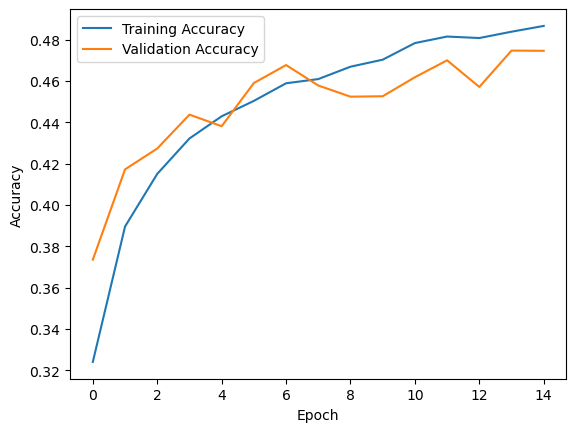

In [28]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

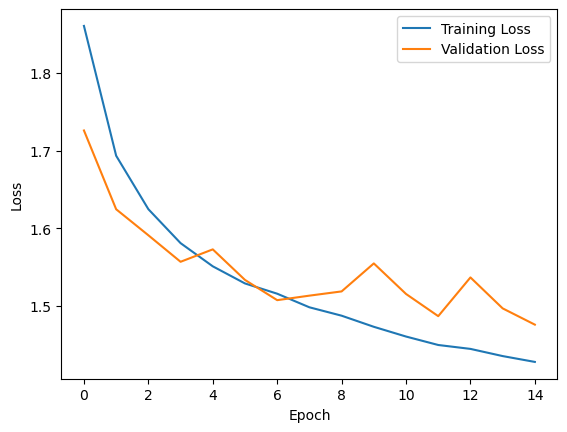

In [29]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Creating a Convolutional Neural Network Model

In [60]:
model2 = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(120, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')

    
    

])

In [61]:
model2.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_14 (Conv2D)          (None, 30, 30, 64)        1792      
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 15, 15, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_15 (Conv2D)          (None, 13, 13, 128)       73856     
                                                                 
 max_pooling2d_15 (MaxPoolin  (None, 6, 6, 128)        0         
 g2D)                                                            
                                                                 
 flatten_9 (Flatten)         (None, 4608)              0         
                                                                 
 dense_17 (Dense)            (None, 120)              

In [62]:
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history2 = model2.fit(
    x_train, 
    y_train, 
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
1250/1250 [==============================] - 9s 7ms/step - loss: 1.4742 - accuracy: 0.4572 - val_loss: 1.2452 - val_accuracy: 0.5482
Epoch 2/15
1250/1250 [==============================] - 8s 7ms/step - loss: 1.1053 - accuracy: 0.6067 - val_loss: 1.0883 - val_accuracy: 0.6163
Epoch 3/15
 955/1250 [=====================>........] - ETA: 1s - loss: 0.9390 - accuracy: 0.6681

In [ ]:
train_loss, train_acc = model2.evaluate(x_train,  y_train, verbose=2)
print('\nTest accuracy:', train_acc)

In [ ]:
test_loss, test_acc = model2.evaluate(x_test,  y_test, verbose=2)
print('\nTest accuracy:', test_acc)

In [ ]:
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Creating a Regularized Convolutional Neural Network Model

In [53]:
model3 = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(120, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(10, activation='softmax')
    

])

In [54]:
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [55]:
history3 = model3.fit(
    x_train, 
    y_train, 
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
1250/1250 [==============================] - 10s 7ms/step - loss: 1.8148 - accuracy: 0.3979 - val_loss: 1.5671 - val_accuracy: 0.4709
Epoch 2/15
1250/1250 [==============================] - 9s 7ms/step - loss: 1.4431 - accuracy: 0.5287 - val_loss: 1.4413 - val_accuracy: 0.5272
Epoch 3/15
1250/1250 [==============================] - 9s 7ms/step - loss: 1.3172 - accuracy: 0.5849 - val_loss: 1.2667 - val_accuracy: 0.6034
Epoch 4/15
1250/1250 [==============================] - 8s 7ms/step - loss: 1.2382 - accuracy: 0.6157 - val_loss: 1.2114 - val_accuracy: 0.6312
Epoch 5/15
1250/1250 [==============================] - 8s 7ms/step - loss: 1.1877 - accuracy: 0.6360 - val_loss: 1.2841 - val_accuracy: 0.6037
Epoch 6/15
1250/1250 [==============================] - 9s 7ms/step - loss: 1.1491 - accuracy: 0.6504 - val_loss: 1.2040 - val_accuracy: 0.6268
Epoch 7/15
1250/1250 [==============================] - 10s 8ms/step - loss: 1.1203 - accuracy: 0.6617 - val_loss: 1.1466 - val_accurac

In [56]:
train_loss, train_acc = model3.evaluate(x_train,  y_train, verbose=2)

print('\nTest accuracy:', train_acc)

1563/1563 - 4s - loss: 0.9087 - accuracy: 0.7437 - 4s/epoch - 3ms/step

Test accuracy: 0.7437199950218201


In [57]:
test_loss, test_acc = model3.evaluate(x_test,  y_test, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - loss: 1.0460 - accuracy: 0.6946 - 1s/epoch - 4ms/step

Test accuracy: 0.694599986076355


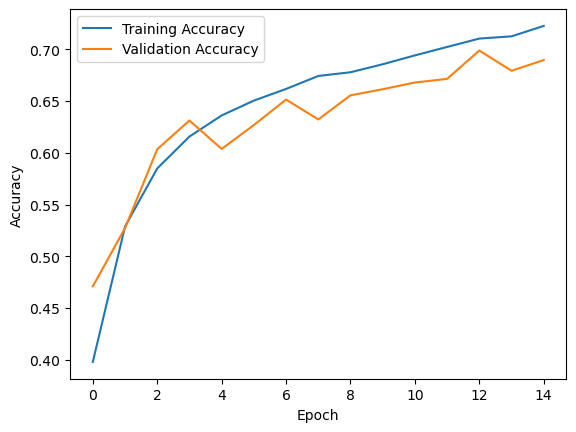

In [58]:
plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

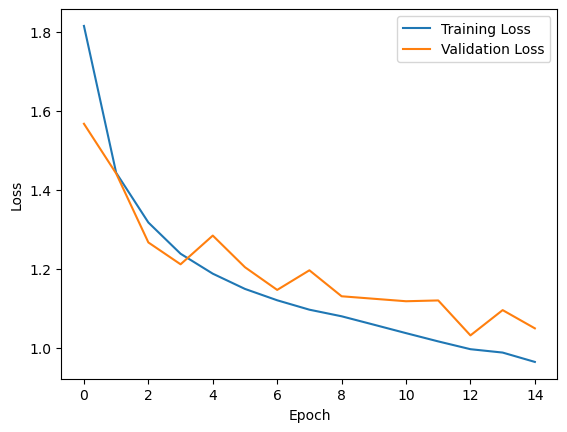

In [59]:
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()